In [29]:
# Part a)
#i)
import pandas as pd
import matplotlib.pyplot as plt
data_path="data/question_5_data/train.csv"
df = pd.read_csv(data_path)
print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= First 5 rows =================\n")
print(df.head())

Shape: (8693, 14)
Data types:
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

 ================= First 5 rows =================

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maha

6 are numerical and 8 are categorical (Considering ID a string)

--- Missing Data Summary ---
              Missing Values  Percentage (%)
CryoSleep                217        2.496261
ShoppingMall             208        2.392730
VIP                      203        2.335212
HomePlanet               201        2.312205
Name                     200        2.300702
Cabin                    199        2.289198
VRDeck                   188        2.162660
Spa                      183        2.105142
FoodCourt                183        2.105142
Destination              182        2.093639
RoomService              181        2.082135
Age                      179        2.059128
PassengerId                0        0.000000
Transported                0        0.000000


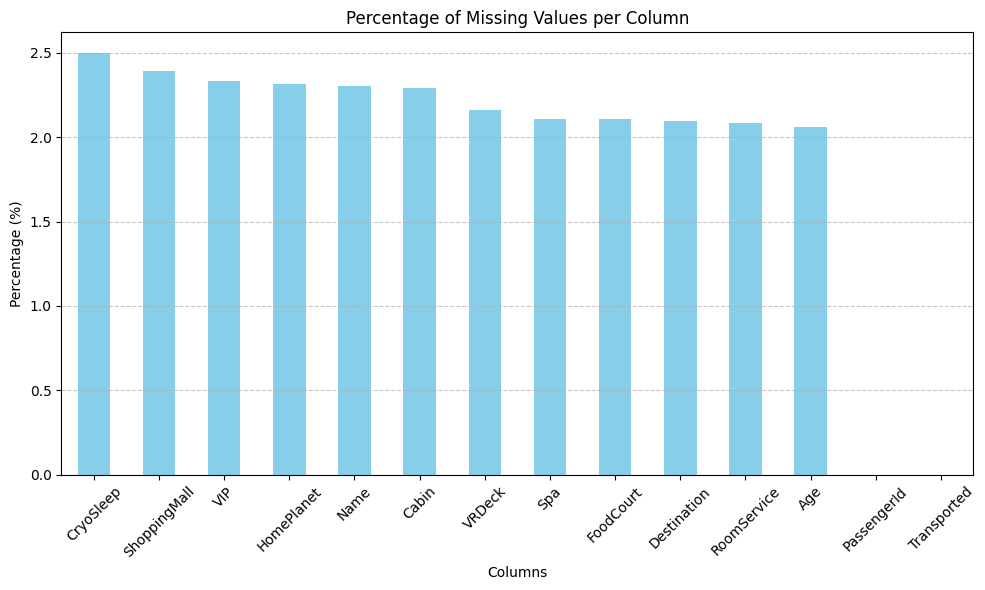

In [30]:
#ii)
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

#Create DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentages
}).sort_values(by='Missing Values', ascending=False)


print("--- Missing Data Summary ---")
print(missing_df)

# 4. Visualize the results
plt.figure(figsize=(10, 6))
missing_df['Percentage (%)'].plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
# iii)
num_transported = (df['Transported']==True)
print (f"Percentage of passengers transported: {100*num_transported.sum()/df['Transported'].count():.2f}%")

Percentage of passengers transported: 50.36%


The dataset is roughly balanced

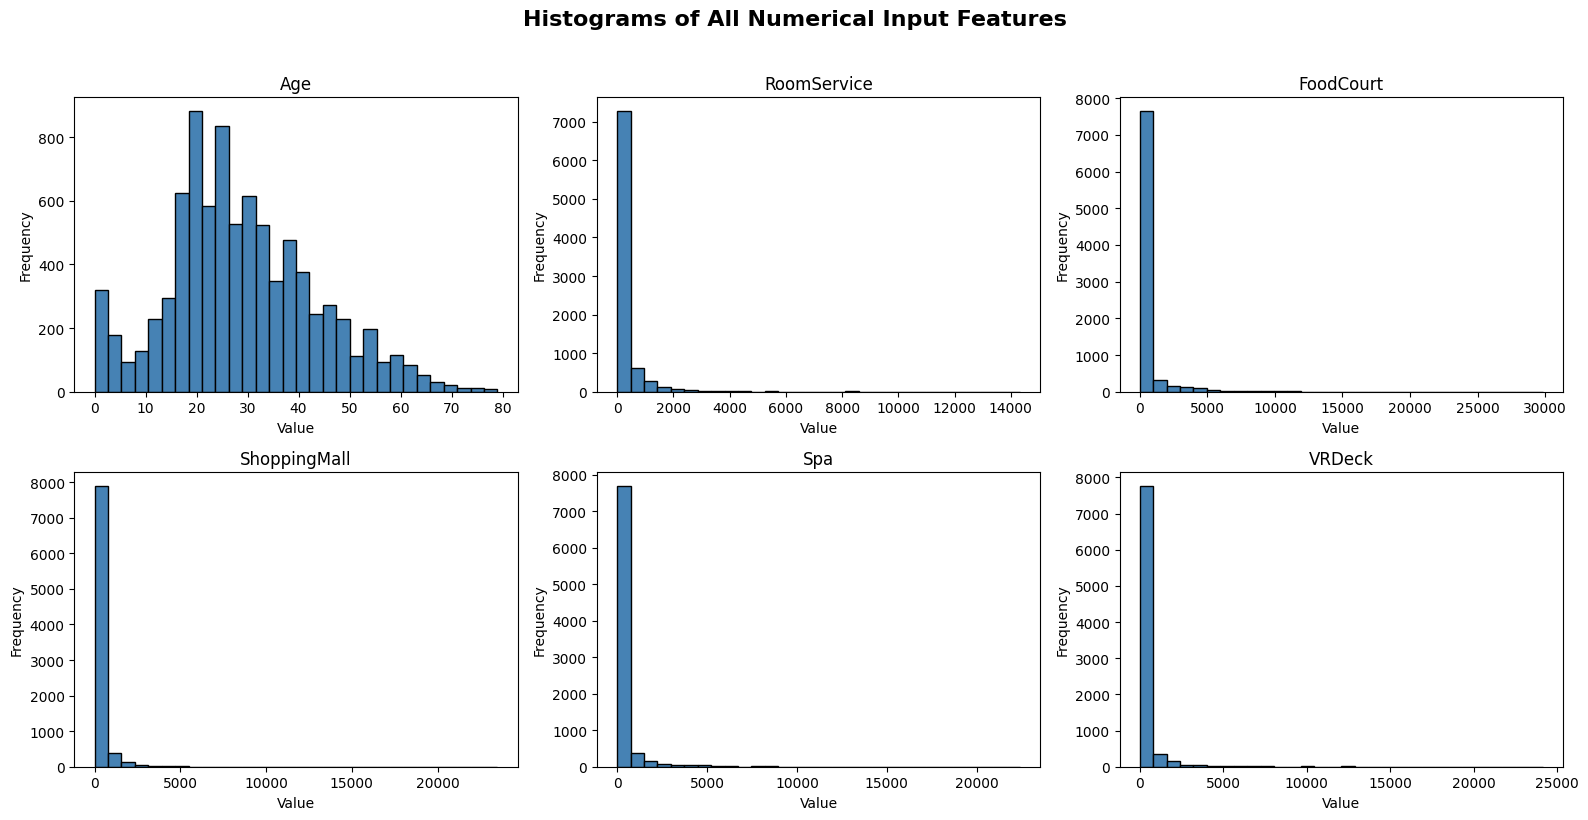

In [32]:
# iv)
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Determine grid size for subplots
n_features = len(numerical_features)
ncols = 3
nrows = (n_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # Dropping NaN values for plotting
    axes[i].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histograms of All Numerical Input Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


All the features except for age are very heavily right skewed, which means most passengers did not have access to those in the spaceship

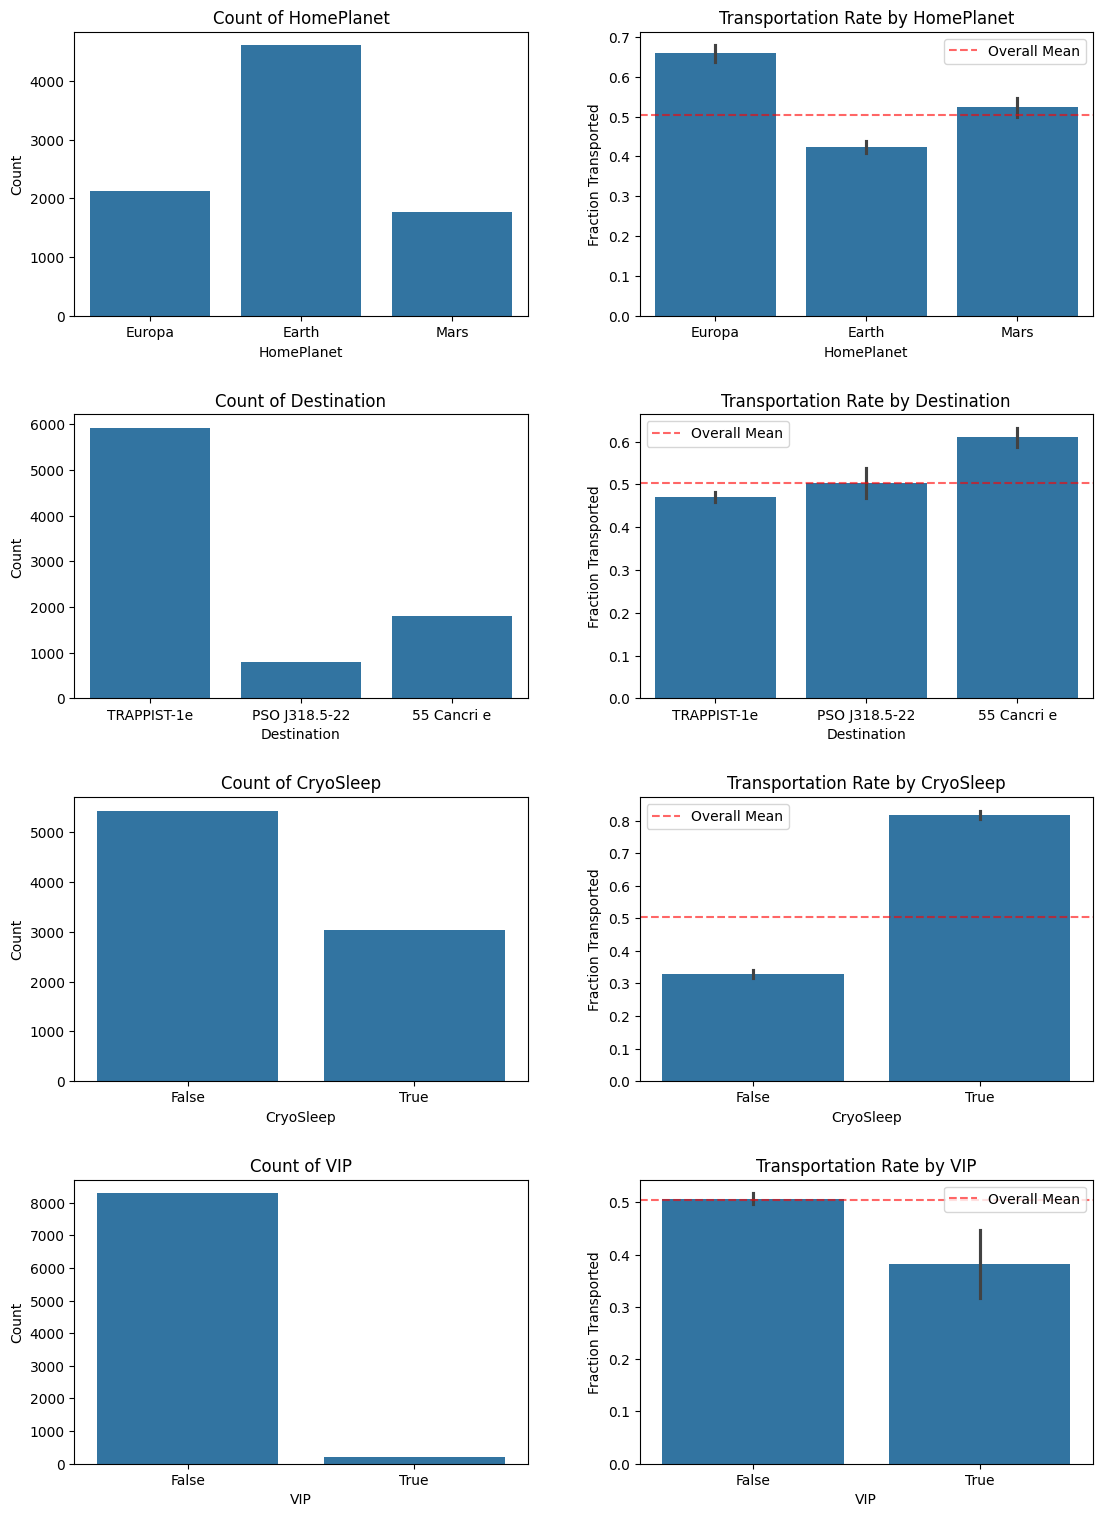

In [33]:
# v)
import seaborn as sns

categorical_features = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
fig.tight_layout(pad=5.0)

for i, col in enumerate(categorical_features):
    
    sns.countplot(data=df, x=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'Count of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Count')
    
    sns.barplot(data=df, x=col, y='Transported', ax=axes[i, 1])
    axes[i, 1].set_title(f'Transportation Rate by {col}', fontsize=12)
    axes[i, 1].set_ylabel('Fraction Transported')
    # Optional: Add a horizontal line representing the baseline transportation rate
    baseline_rate = df['Transported'].mean()
    axes[i, 1].axhline(baseline_rate, color='red', linestyle='--', alpha=0.6, label='Overall Mean')
    axes[i, 1].legend()

plt.show()

The Cryo Sleep category appears to be the most predictive of the target since around 80% of passengers in Cryo Sleep were transported

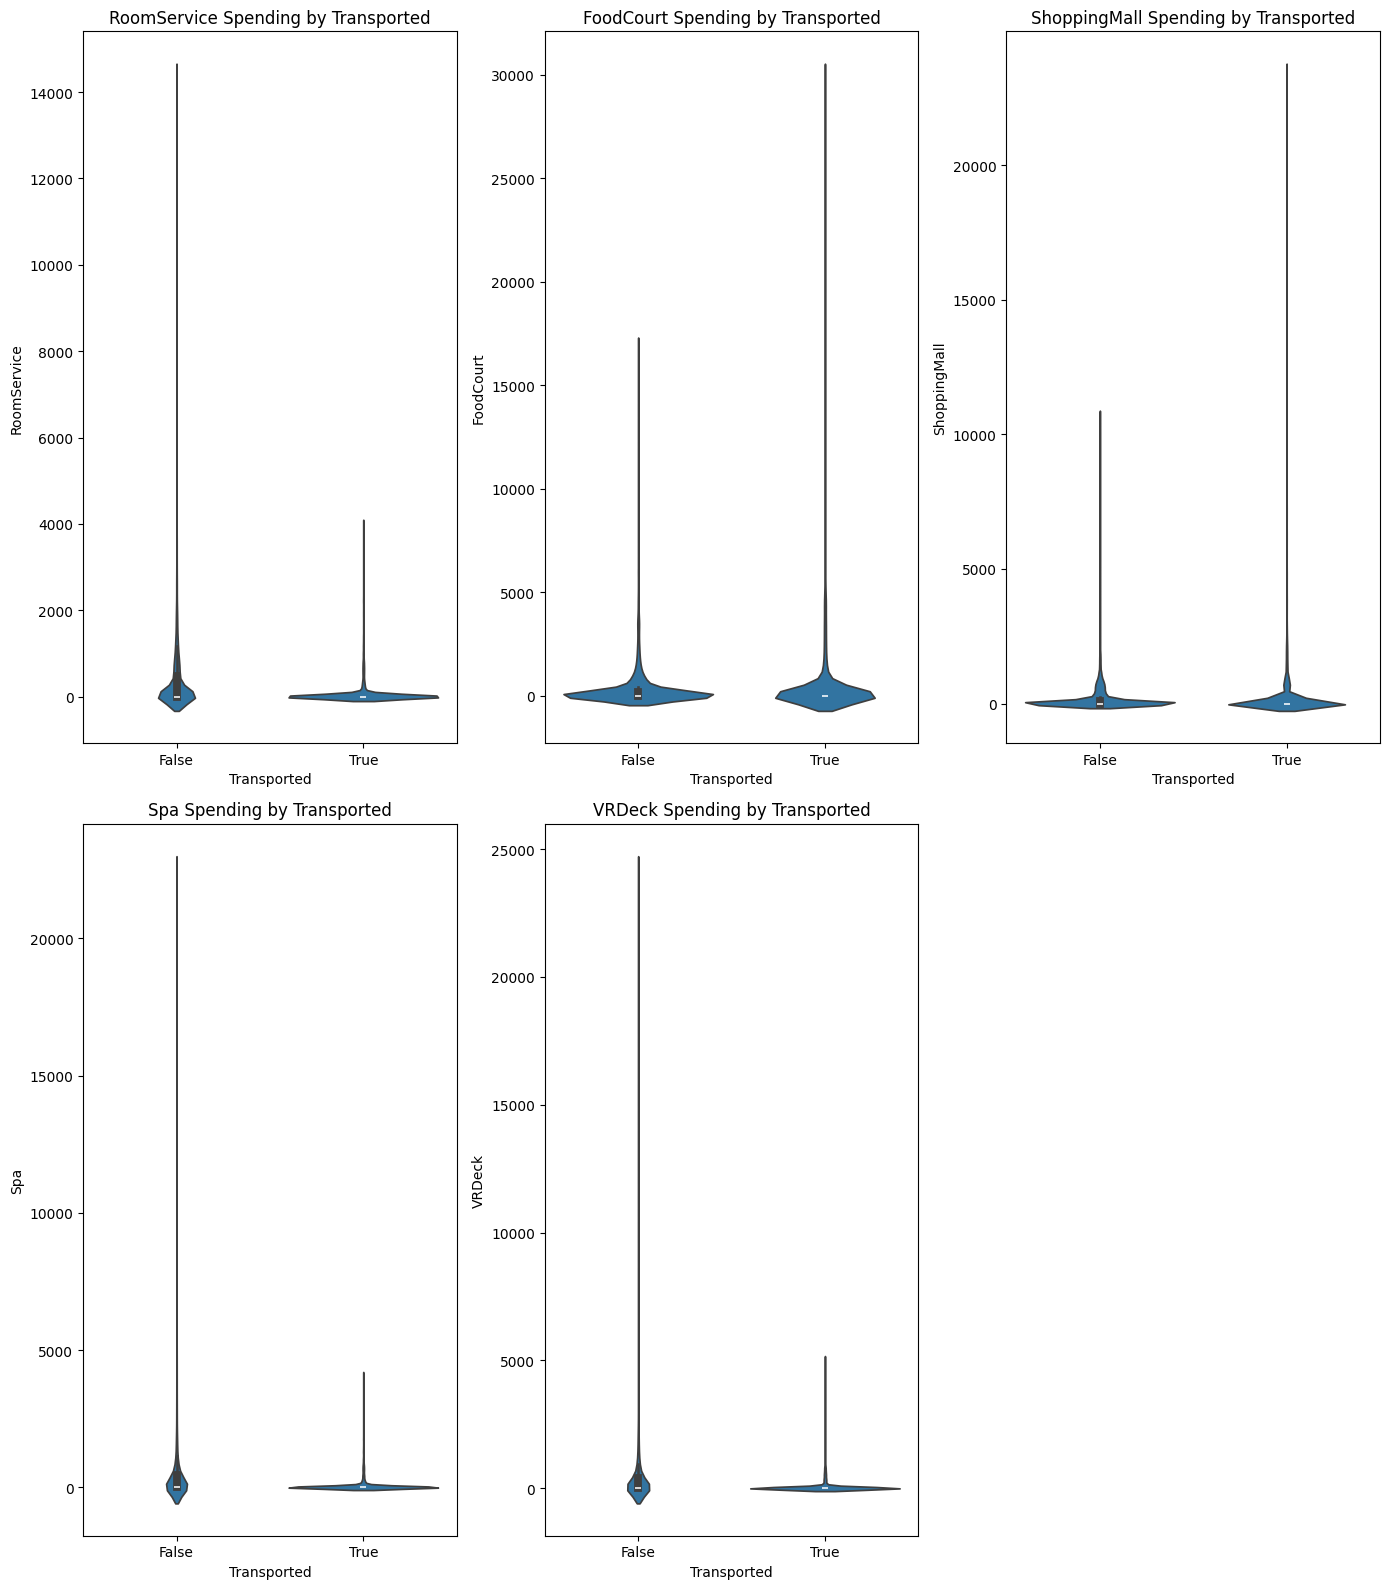

In [34]:
# vi)

import numpy as np
spending_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(spending_features):
    # Using a violin plot. Box plot can be used by swapping sns.violinplot with sns.boxplot
    # We apply a log transformation (log1p) because spending data is highly right-skewed 
    # with many passengers spending 0. This makes the plots much easier to read.
    sns.violinplot(
        data=df, 
        x='Transported', 
        y=df[col], # log(1 + x) to handle 0s
        ax=axes[i], 
    )
    axes[i].set_title(f'{col} Spending by Transported', fontsize=12)
    axes[i].set_ylabel(f'{col}')

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Transported passengers tend to spend significantly less, which reinforces the hypothesis that being in cryo sleep is one of the most important factors to predict the target (since sleeping passengers do not spend)

In [35]:
# Part b)
# i)
# Drop the uninformative columns from the dataframe
df = df.drop(columns=['PassengerId', 'Name', 'Cabin'])

# Verify the columns are dropped
print(df.columns)

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported'],
      dtype='str')


Passenger ID gives us no information about the passengers: it is simply a unique identifier (same logic applies to name, except it is not unique). Cabin could be useful, but it is too complex to be processed in the scope of this problem.

In [36]:
#ii)
cat_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

# Loop through each column to calculate and apply the mode
for col in cat_cols:
    mode_value = df[col].mode()[0]
    
    # Fill missing (NaN) values with the mode
    df[col] = df[col].fillna(mode_value)
    
    # Optional: Print out what was imputed for your records
    print(f"Filled missing values in '{col}' with: {mode_value}")


Filled missing values in 'HomePlanet' with: Earth
Filled missing values in 'Destination' with: TRAPPIST-1e
Filled missing values in 'CryoSleep' with: False
Filled missing values in 'VIP' with: False


In [37]:
# iii)
spending_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Age']
for feature in spending_features:
    mean_value = df[feature].mean()
    df[feature] = df[feature].fillna(mean_value)
    print(f"Filled missing values in '{feature}' with mean: {mean_value}")

Filled missing values in 'RoomService' with mean: 224.687617481203
Filled missing values in 'FoodCourt' with mean: 458.07720329024676
Filled missing values in 'ShoppingMall' with mean: 173.72916912197996
Filled missing values in 'Spa' with mean: 311.1387779083431
Filled missing values in 'VRDeck' with mean: 304.8547912992357
Filled missing values in 'Age' with mean: 28.82793046746535


In [38]:
# iv)
# We can just convert the booleans to ints
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)

df = pd.get_dummies(df, columns=['HomePlanet', 'Destination'], drop_first=True, dtype=int)

num_features = df.shape[1] - 1 if 'Transported' in df.columns else df.shape[1]
print(f"Total features after encoding: {num_features}")

# 4. Print the first 5 rows to verify
print("\nFirst 5 rows of the processed feature matrix:")
display(df.head())

Total features after encoding: 12

First 5 rows of the processed feature matrix:


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,1,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,1,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,0,0,0,1


In [39]:
# v)
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

X = df.drop(columns=['Transported'])
y = df['Transported'] #target

# Separate out the Test set (20%) from the Train+Val set (80%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Ensures class balance is maintained
)

# Separate the Train+Val set (80%) into Train (60%) and Val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_train_val # Ensures class balance is maintained
)
X_train_raw = X_train.copy() # Keep a copy of the raw training features for later use in part (e)
X_test_raw = X_test.copy()   # Keep a copy of the raw test features for later use in part (e)
X_val_raw = X_val.copy()     # Keep a copy of the raw validation features for later use in part (e)

# Verify
print(f"Total samples:  {len(df)}")
print("-" * 30)
print(f"Training set:   {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set:       {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")


Total samples:  8693
------------------------------
Training set:   5215 samples (60.0%)
Validation set: 1739 samples (20.0%)
Test set:       1739 samples (20.0%)


In [40]:
# vi)
for feature in X_train.columns:
    mean = X_train[feature].mean()
    std = X_train[feature].std()
    X_train[feature] = (X_train[feature] - mean) / std
    X_val[feature] = (X_val[feature] - mean) / std
    X_test[feature] = (X_test[feature] - mean) / std
    

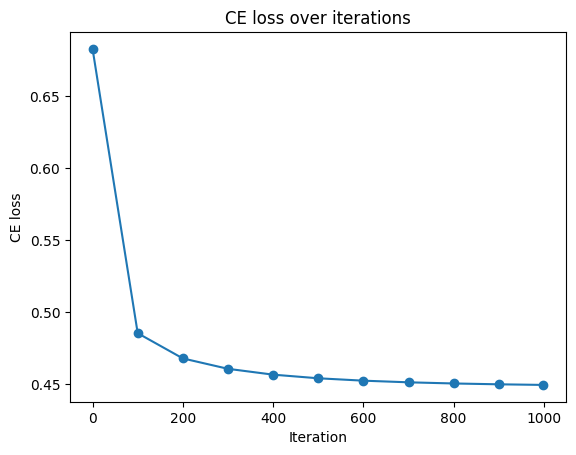

In [41]:
#Part c)
# i) Part i is done by hand in the first page of the submission.
# ii)
#helper functions:
def sigmoid(z):
    z = np.clip(z, -250, 250) 
    return 1 / (1 + np.exp(-z))

def compute_ce_loss(X, y, w):
    N = len(y)
    y_hat = sigmoid(np.dot(X, w))
    
    # Add a tiny value (epsilon) to prevent taking log(0)
    epsilon = 1e-15 
    loss = - (1/N) * np.sum(y * np.log(y_hat + epsilon) + (1 - y) * np.log(1 - y_hat + epsilon))
    return loss

def gradient_descent_ce(X, y, learning_rate=0.1, num_iterations=1000):
    N, num_features = X.shape
    
    # Initialize weights w to a vector of zeros
    w = np.zeros(num_features)
    
    # Store the loss at each step to plot convergence later
    loss_history = []
    
    for t in range(num_iterations):
        # Predicted probabilities: sigma(w^T * X)
        y_hat = sigmoid(np.dot(X, w))
        
        # Gradient: (1/N) * X^T * (y_hat - y)
        gradient = (1/N) * np.dot(X.T, (y_hat - y))
        
        # w(t+1)
        w = w - learning_rate * gradient
        
        # 4. Calculate loss every 100 iterations or at the very last
        if t % 100 == 0 or t == num_iterations - 1:
            loss = compute_ce_loss(X, y, w)
            loss_history.append((t, loss))
            
    return w, loss_history

w, loss_history = gradient_descent_ce(X_train.values, y_train.values, learning_rate=0.1, num_iterations=1000)

# Unpack the list of tuples into two separate lists
iterations, losses = zip(*loss_history)

# Plot the unpacked lists
plt.plot(iterations, losses, marker='o')
plt.title('CE loss over iterations')
plt.xlabel('Iteration')
plt.ylabel('CE loss')
plt.show()

In [42]:
#iii)
train_probs = sigmoid(np.dot(X_train.values, w))
val_probs = sigmoid(np.dot(X_val.values, w))

train_preds = (train_probs >= 0.5).astype(int)
val_preds = (val_probs >= 0.5).astype(int)

train_accuracy = np.mean(train_preds == y_train.values)
val_accuracy = np.mean(val_preds == y_val.values)

print(f"Training Accuracy:   {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Training Accuracy:   78.83%
Validation Accuracy: 77.00%


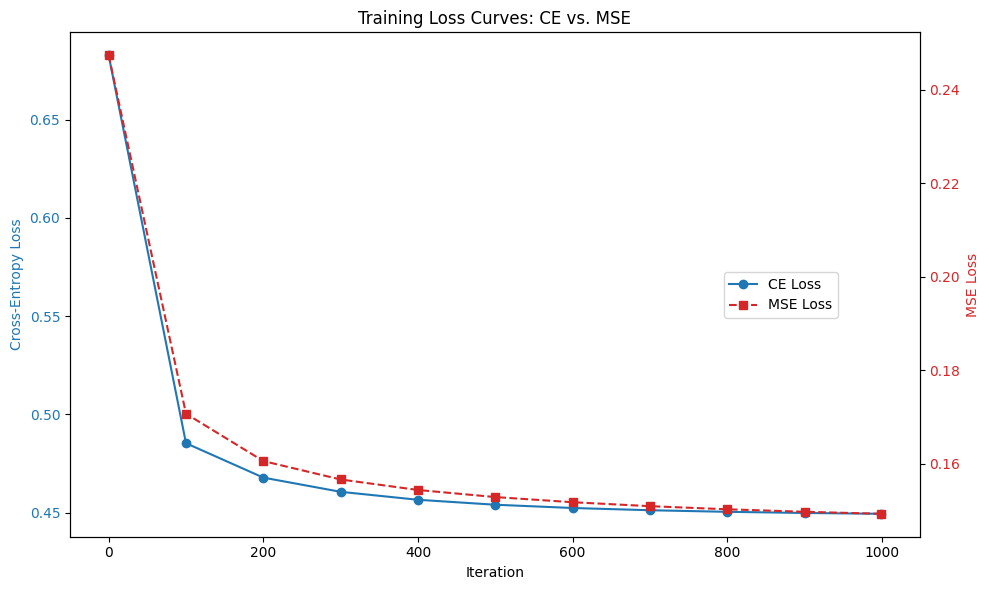

In [43]:
# Part d)
# i) Part i is done by hand in the first page of the submission.
# ii)
import numpy as np
import matplotlib.pyplot as plt


def compute_mse_loss(X, y, w):
    N = len(y)
    y_hat = sigmoid(np.dot(X, w))
    loss = (1/N) * np.sum((y_hat - y)**2)
    return loss

#Same as ce, with different loss function
def gradient_descent_mse(X, y, learning_rate=0.1, num_iterations=1000):
    N, num_features = X.shape
    w = np.zeros(num_features)
    loss_history = []
    
    for t in range(num_iterations):
        y_hat = sigmoid(np.dot(X, w))
        
        gradient = (2/N) * np.dot(X.T, (y_hat - y) * y_hat * (1 - y_hat))
        
        w = w - learning_rate * gradient
        
        if t % 100 == 0 or t == num_iterations - 1:
            loss = compute_mse_loss(X, y, w)
            loss_history.append((t, loss))
            
    return w, loss_history

w_mse, mse_loss_history = gradient_descent_mse(
    X_train.values, y_train.values, 
    learning_rate=0.1, 
    num_iterations=1000
)

# Unpack both histories
ce_iterations, ce_losses = zip(*loss_history) # from (c)(ii)
mse_iterations, mse_losses = zip(*mse_loss_history)

# 3. Plotting with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Cross-Entropy on the primary (left) y-axis
color_ce = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cross-Entropy Loss', color=color_ce)
ax1.plot(ce_iterations, ce_losses, color=color_ce, marker='o', label='CE Loss')
ax1.tick_params(axis='y', labelcolor=color_ce)

# MSE on the secondary (right) y-axis
ax2 = ax1.twinx()  
color_mse = 'tab:red'
ax2.set_ylabel('MSE Loss', color=color_mse)  
ax2.plot(mse_iterations, mse_losses, color=color_mse, marker='s', linestyle='--', label='MSE Loss')
ax2.tick_params(axis='y', labelcolor=color_mse)

# Title and legends
plt.title('Training Loss Curves: CE vs. MSE')
fig.tight_layout() 
fig.legend(loc='center right', bbox_to_anchor=(0.85, 0.5))

plt.show()

In [44]:
# iii)
train_probs = sigmoid(np.dot(X_train.values, w))
val_probs = sigmoid(np.dot(X_val.values, w))

train_preds = (train_probs >= 0.5).astype(int)
val_preds = (val_probs >= 0.5).astype(int)

train_accuracy = np.mean(train_preds == y_train.values)
val_accuracy = np.mean(val_preds == y_val.values)

print(f"Training Accuracy for CE:   {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy for CE: {val_accuracy * 100:.2f}%")

train_probs_mse = sigmoid(np.dot(X_train.values, w_mse))
val_probs_mse = sigmoid(np.dot(X_val.values, w_mse))

train_preds_mse = (train_probs_mse >= 0.5).astype(int)
val_preds_mse = (val_probs_mse >= 0.5).astype(int)

train_accuracy_mse = np.mean(train_preds_mse == y_train.values)
val_accuracy_mse = np.mean(val_preds_mse == y_val.values)

print(f"MSE Training Accuracy for MSE:   {train_accuracy_mse * 100:.2f}%")
print(f"MSE Validation Accuracy for MSE: {val_accuracy_mse * 100:.2f}%")

Training Accuracy for CE:   78.83%
Validation Accuracy for CE: 77.00%
MSE Training Accuracy for MSE:   78.95%
MSE Validation Accuracy for MSE: 77.11%


The MSE performance is slightly better than CE, although similar. The slightly edge of MSE is expected because of the sigmoid derivative term which makes it very hard to correct very confident labels. The difference is not as noticible in this problems because weights were initialize at one of the extremes (all zeros)

In [47]:
# Part 3)
# i)

spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

raw_spend_train = X_train_raw[spending_cols].sum(axis=1)
raw_spend_val = X_val_raw[spending_cols].sum(axis=1)

X_train['NoSpending'] = (raw_spend_train == 0).astype(int)
X_val['NoSpending'] = (raw_spend_val == 0).astype(int)

# log1p is log (1 + x)
log_spend_train = np.log1p(raw_spend_train)
log_spend_val = np.log1p(raw_spend_val)

#standardize
log_spend_mean = log_spend_train.mean()
log_spend_std = log_spend_train.std()
X_train['LogTotalSpending'] = (log_spend_train - log_spend_mean) / log_spend_std
X_val['LogTotalSpending'] = (log_spend_val - log_spend_mean) / log_spend_std

# Retrain the CE model
w_eng, loss_history_eng = gradient_descent_ce(
    X_train.values, y_train.values, 
    learning_rate=0.1, 
    num_iterations=1000
)

train_probs_eng = sigmoid(np.dot(X_train.values, w_eng))
val_probs_eng = sigmoid(np.dot(X_val.values, w_eng))

train_preds_eng = (train_probs_eng >= 0.5).astype(int)
val_preds_eng = (val_probs_eng >= 0.5).astype(int)

train_acc_eng = np.mean(train_preds_eng == y_train.values)
val_acc_eng = np.mean(val_preds_eng == y_val.values)

print(f"New features Training Accuracy:   {train_acc_eng * 100:.2f}%")
print(f"New features Validation Accuracy: {val_acc_eng * 100:.2f}%")

New features Training Accuracy:   79.04%
New features Validation Accuracy: 77.57%


The new features help increasing the validation accuracy by 0.57%

In [ ]:
# ii)
